In [1]:
import os; print(os.getcwd())

/home/llaurabat/ff_project/frugal-flows/validation


# Basic Experiment

In [7]:
import sys, os
sys.path.append("./morphomnist") 

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from prepare_data import prepare_flow_data, unflatten, inverse_logit

SIZE = 16
data = prepare_flow_data("morphomnist/data/", size=SIZE, n_samples=10000, seed=0)
{k: (v.shape if hasattr(v, "shape") else v) for k, v in data.items()}

{'Y': (10000, 256),
 'X': (10000, 1),
 'Z': (10000, 11),
 'Y0': (10000, 256),
 'Y1': (10000, 256),
 'ITE': (10000, 256),
 'ATE': (256,),
 'image_size': 16,
 'seed': 0}

Y1 and Y0 are the two potential outcomes under treatment or no treatement. If X=0, then Y=Y0 and viceversa

In [16]:
data.keys()

dict_keys(['Y', 'X', 'Z', 'Y0', 'Y1', 'ITE', 'ATE', 'image_size', 'seed'])

In [14]:
data["Y"]

Array([[-3.651383 , -3.5393066, -3.65699  , ..., -3.6077983, -3.567728 ,
        -3.5308626],
       [-3.6296382, -3.5878017, -3.6266909, ..., -3.538871 , -3.5524426,
        -3.6108823],
       [-3.6619642, -3.5673425, -3.600374 , ..., -3.544411 , -3.6228626,
        -3.5532658],
       ...,
       [-3.597325 , -3.5961568, -3.5863738, ..., -3.5413404, -3.6087368,
        -3.5539653],
       [-3.5321524, -3.628764 , -3.6056073, ..., -3.557846 , -3.636417 ,
        -3.5253806],
       [-3.648492 , -3.5994987, -3.5589302, ..., -3.628603 , -3.6524212,
        -3.5518725]], dtype=float32)

In [17]:
data["X"]

Array([[0.],
       [0.],
       [1.],
       ...,
       [0.],
       [1.],
       [1.]], dtype=float32)

ITE is supposed to be zero at the corners where there's no digit

max |ITE|: 0.83849645
nonzero fraction: 0.17704296875
per-unit nonzero pixels: [29 33 32 66 52 38 35 37 68 50]


Text(0.5, 1.0, 'mean |ITE| per pixel')

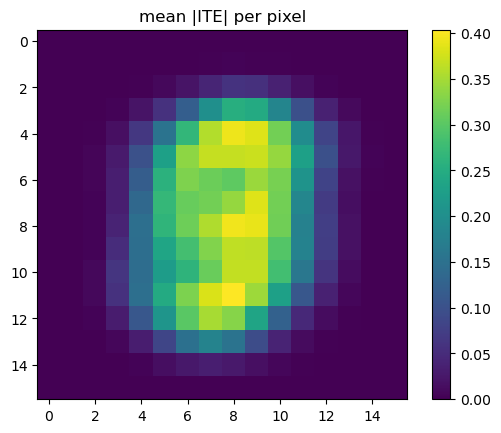

In [20]:
ITE = np.asarray(data["ITE"])
print("max |ITE|:", np.abs(ITE).max())
print("nonzero fraction:", (ITE != 0).mean())          # expect roughly the ink fraction, ~0.15–0.3
print("per-unit nonzero pixels:", (ITE != 0).sum(axis=1)[:10])
plt.imshow(np.abs(ITE).mean(axis=0).reshape(SIZE, SIZE)); plt.colorbar()
plt.title("mean |ITE| per pixel")  # should light up where digits are

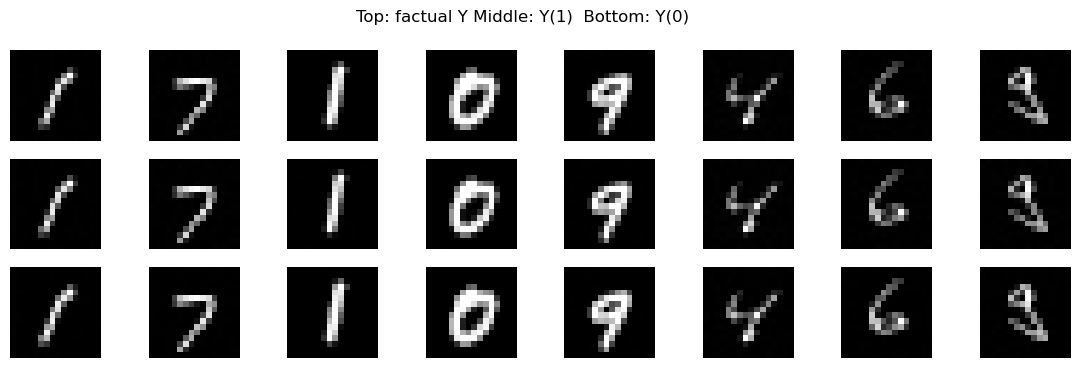

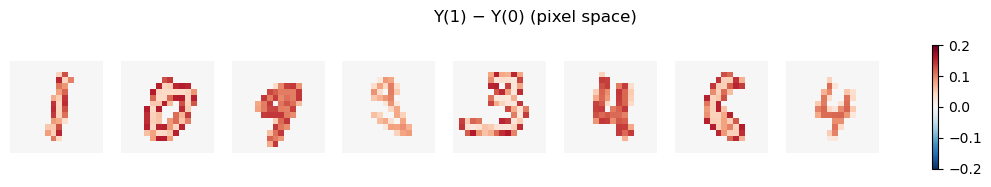

In [24]:
fig, axes = plt.subplots(3, 8, figsize=(14, 4))
imgs = inverse_logit(np.asarray(data["Y"][:8]))          # back to [0,1]
for i, ax in enumerate(axes[0]):
    ax.imshow(unflatten(imgs[i], SIZE)[0], cmap="gray"); ax.axis("off")
axes[0, 0].set_ylabel("factual", rotation=0)

# untreated potential outcome for the same units
imgs0 = inverse_logit(np.asarray(data["Y0"][:8]))
for i, ax in enumerate(axes[1]):
    ax.imshow(unflatten(imgs0[i], SIZE)[0], cmap="gray"); ax.axis("off")

# treated potential outcome for the same units
imgs1 = inverse_logit(np.asarray(data["Y1"][:8]))
for i, ax in enumerate(axes[2]):
    ax.imshow(unflatten(imgs1[i], SIZE)[0], cmap="gray"); ax.axis("off")
plt.suptitle("Top: factual Y Middle: Y(1)  Bottom: Y(0)")
plt.show()


T = np.asarray(data["X"]).flatten().astype(bool)
diff = inverse_logit(np.asarray(data["Y1"])) - inverse_logit(np.asarray(data["Y0"]))

idx = np.where(T)[0][:8]
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in zip(idx, axes):
    im = ax.imshow(diff[i].reshape(SIZE, SIZE), cmap="RdBu_r",
                   vmin=-0.2, vmax=0.2)
    ax.axis("off")
plt.suptitle("Y(1) − Y(0) (pixel space)")
plt.colorbar(im, ax=axes, shrink=0.8)
plt.show()

treated fraction: 0.493


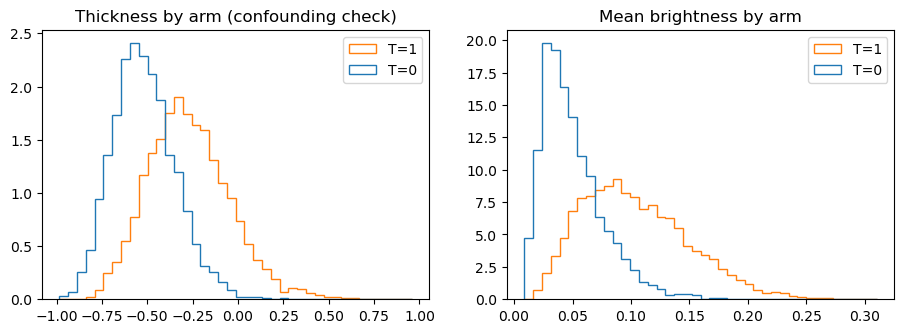

In [8]:
T = np.asarray(data["X"]).flatten()
thickness = np.asarray(data["Z"])[:, 0]
print(f"treated fraction: {T.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist([thickness[T==0], thickness[T==1]], bins=40, label=["T=0", "T=1"], density=True, histtype="step")
axes[0].legend(); axes[0].set_title("Thickness by arm (confounding check)")

# naive vs adjusted difference in mean brightness
mean_bright = inverse_logit(Y).mean(axis=1)
axes[1].hist([mean_bright[T==0], mean_bright[T==1]], bins=40, label=["T=0", "T=1"], density=True, histtype="step")
axes[1].legend(); axes[1].set_title("Mean brightness by arm")
plt.show()

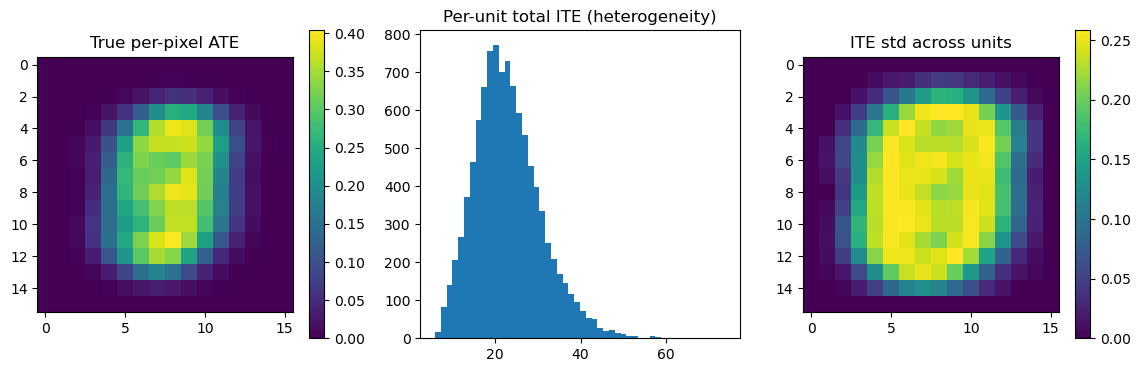

In [9]:
ATE = np.asarray(data["ATE"])           # (K,)
ITE = np.asarray(data["ITE"])           # (n, K)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im = axes[0].imshow(ATE.reshape(SIZE, SIZE)); plt.colorbar(im, ax=axes[0])
axes[0].set_title("True per-pixel ATE")

axes[1].hist(ITE.sum(axis=1), bins=50)
axes[1].set_title("Per-unit total ITE (heterogeneity)")

im = axes[2].imshow(ITE.std(axis=0).reshape(SIZE, SIZE)); plt.colorbar(im, ax=axes[2])
axes[2].set_title("ITE std across units")
plt.show()

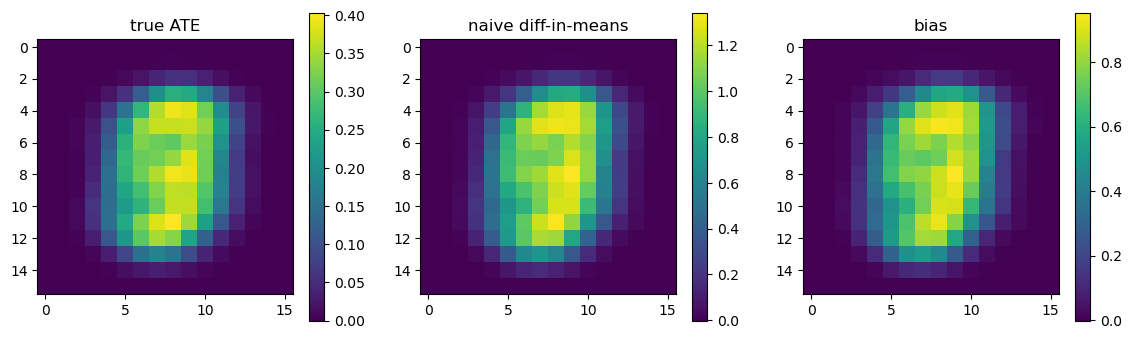

mean |bias| = 0.2186


In [10]:
# Naive per-pixel difference of means — biased because T is confounded
naive = Y[T==1].mean(axis=0) - Y[T==0].mean(axis=0)
true_flowspace = ITE.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, v, title in zip(axes, [true_flowspace, naive, naive - true_flowspace],
                        ["true ATE", "naive diff-in-means", "bias"]):
    im = ax.imshow(v.reshape(SIZE, SIZE)); plt.colorbar(im, ax=ax); ax.set_title(title)
plt.show()
print(f"mean |bias| = {np.abs(naive - true_flowspace).mean():.4f}")

## Proper experiments

Build all three experiments.

We validate the frugal flow (FF) on MorphoMNIST under a family of synthetic interventions
designed so that the target estimand is known \emph{exactly}, by construction rather than by
Monte-Carlo approximation. The experiments form a ladder in which exactly one design feature
changes at each rung: randomised assignment $\to$ confounded assignment $\to$ confounded
assignment with a heterogeneous effect. This isolates the contribution of each difficulty to
the estimation error.

All experiments are generated by a single parameterised DGP (\texttt{prepare\_morphomnist\_exps.py}); the three rungs differ only in the value of three scalar knobs.

In [1]:
import sys, os
sys.path.append("./morphomnist")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prepare_data import unflatten, inverse_logit
from prepare_morphomnist_exps import PRESETS, build_preset, summarise

SIZE = 16
RADIUS = 4   # scale the disc with the grid: r=2 at 8x8 and r=4 at 16x16 both cover ~20% of pixels

# data_dir resolves relative to the module, so this works from any cwd
exps = {name: build_preset(name, size=SIZE, radius=RADIUS) for name in PRESETS}

{k: (tuple(v.shape) if hasattr(v, "shape") else v)
 for k, v in exps["exp3_confounded_heterogeneous"].items() if k != "config"}

{'Y': (5923, 256),
 'X': (5923, 1),
 'Z': (5923, 1),
 'z_cont': (5923, 1),
 'z_discr': (5923, 0),
 'z_cat_idx': (1,),
 'ATE': (256,),
 'ATT': (256,),
 'ATC': (256,),
 'ITE': (5923, 256),
 'Y0': (5923, 256),
 'Y1': (5923, 256),
 'MAP': (256,),
 'FACTOR': (5923, 256),
 'TAU_U': (40,),
 'TAU_PAIRED': (40, 256),
 'TAU_MARGINAL': (40, 256),
 'PROPENSITY': (5923,),
 'THICKNESS': (5923,),
 'image_size': 16,
 'n_units': 5923,
 'n_pixels': 256,
 'preset': 'exp3_confounded_heterogeneous'}

In [2]:
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
summary = pd.DataFrame({name: summarise(d) for name, d in exps.items()})
summary

,exp1_rct_homogeneous,exp2_confounded_homogeneous,exp3_confounded_heterogeneous
preset,exp1_rct_homogeneous,exp2_confounded_homogeneous,exp3_confounded_heterogeneous
n_units,5923,5923,5923
n_pixels,256,256,256
treated_frac,0.5018,0.4932,0.4932
propensity_min,0.5,0.05725,0.05725
propensity_max,0.5,0.9988,0.9988
corr_thickness_treatment,0.01052,0.4723,0.4723
ate_mean,0.2031,0.2031,0.2031
ate_max,1,1,1
ate_exactness,0,0,6.106e-15


ATE minus imposed map, max abs: 0.0
nonzero pixels: 52 of 256


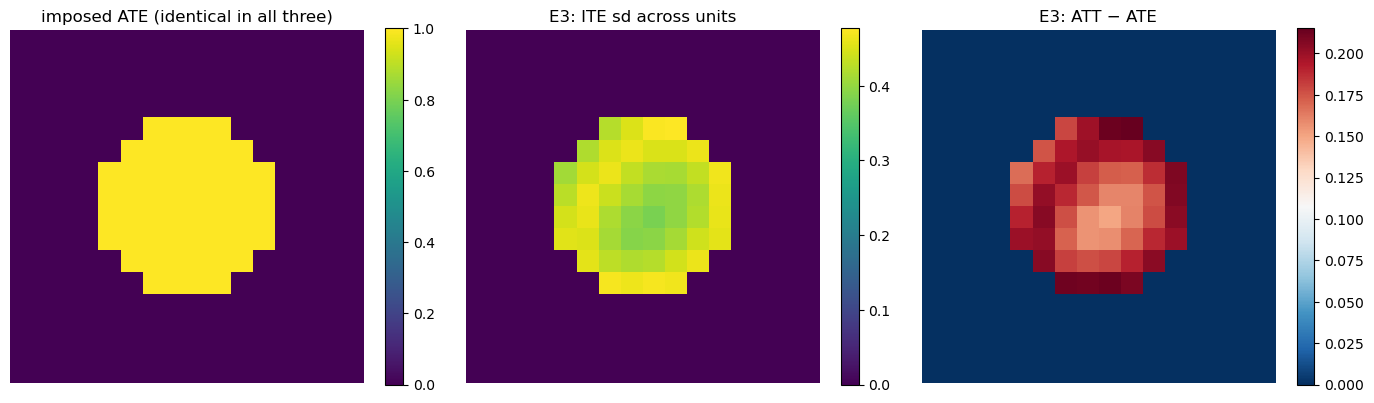

In [3]:
d = exps["exp1_rct_homogeneous"]
print("ATE minus imposed map, max abs:", np.abs(d["ITE"].mean(0) - d["ATE"]).max())
print("nonzero pixels:", int((d["ATE"] != 0).sum()), "of", d["ATE"].size)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
panels = [(exps["exp1_rct_homogeneous"]["ATE"], "imposed ATE (identical in all three)", "viridis"),
          (exps["exp3_confounded_heterogeneous"]["ITE"].std(0), "E3: ITE sd across units", "viridis"),
          (exps["exp3_confounded_heterogeneous"]["ATT"]
           - exps["exp3_confounded_heterogeneous"]["ATE"], "E3: ATT − ATE", "RdBu_r")]
for ax, (v, title, cmap) in zip(axes, panels):
    im = ax.imshow(v.reshape(SIZE, SIZE), cmap=cmap)
    plt.colorbar(im, ax=ax); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

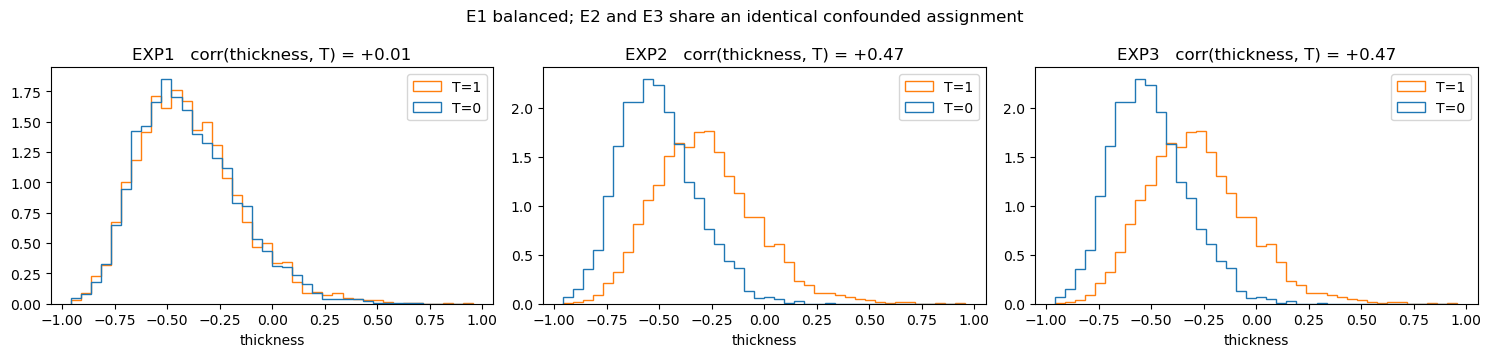

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (name, d) in zip(axes, exps.items()):
    T = np.asarray(d["X"]).ravel().astype(bool)
    ax.hist([d["THICKNESS"][~T], d["THICKNESS"][T]], bins=40,
            label=["T=0", "T=1"], density=True, histtype="step")
    r = np.corrcoef(d["THICKNESS"], T)[0, 1]
    ax.set_title(f"{name.split('_', 1)[0].upper()}   corr(thickness, T) = {r:+.2f}")
    ax.set_xlabel("thickness"); ax.legend()
plt.suptitle("E1 balanced; E2 and E3 share an identical confounded assignment")
plt.tight_layout(); plt.show()

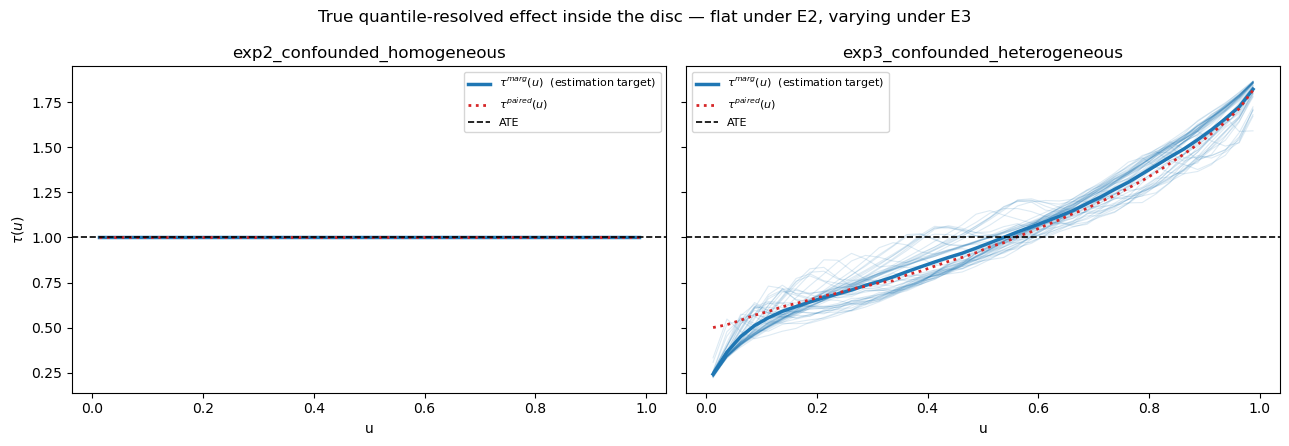

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, name in zip(axes, ["exp2_confounded_homogeneous", "exp3_confounded_heterogeneous"]):
    d = exps[name]
    inside, u = d["ATE"] > 0, d["TAU_U"]
    ax.plot(u, d["TAU_MARGINAL"][:, inside], color="C0", alpha=0.15, lw=0.8)
    ax.plot(u, d["TAU_MARGINAL"][:, inside].mean(1), color="C0", lw=2.5,
            label=r"$\tau^{marg}(u)$  (estimation target)")
    ax.plot(u, d["TAU_PAIRED"][:, inside].mean(1), color="C3", lw=2.0, ls=":",
            label=r"$\tau^{paired}(u)$")
    ax.axhline(d["ATE"][inside].mean(), color="k", ls="--", lw=1.2, label="ATE")
    ax.set_title(name); ax.set_xlabel("u"); ax.legend(fontsize=8)
axes[0].set_ylabel(r"$\tau(u)$")
plt.suptitle("True quantile-resolved effect inside the disc — flat under E2, varying under E3")
plt.tight_layout(); plt.show()

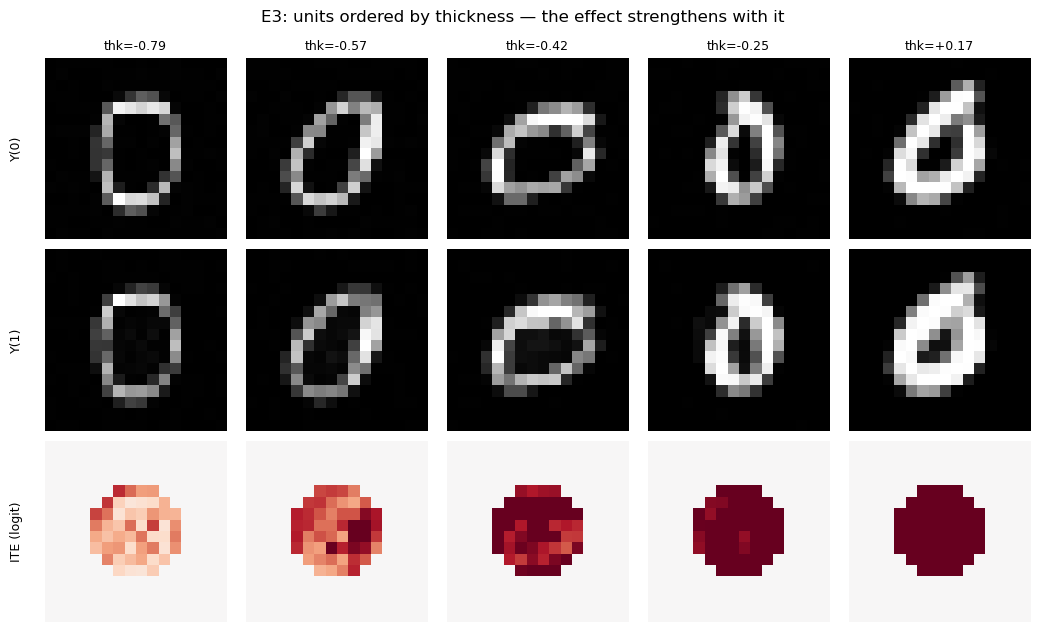

In [6]:
d = exps["exp3_confounded_heterogeneous"]
order = np.argsort(d["THICKNESS"])
pick = order[[int(q * (len(order) - 1)) for q in (0.02, 0.25, 0.5, 0.75, 0.98)]]
rows = [("Y(0)", "gray"), ("Y(1)", "gray"), ("ITE (logit)", "RdBu_r")]

fig, axes = plt.subplots(3, len(pick), figsize=(2.1 * len(pick), 6.4))
for j, i in enumerate(pick):
    vals = [inverse_logit(d["Y0"][i]), inverse_logit(d["Y1"][i]), d["ITE"][i]]
    for row, (lab, cmap) in enumerate(rows):
        kw = dict(vmin=-1, vmax=1) if row == 2 else {}
        axes[row, j].imshow(np.asarray(vals[row]).reshape(SIZE, SIZE), cmap=cmap, **kw)
        axes[row, j].axis("off")
    axes[0, j].set_title(f"thk={d['THICKNESS'][i]:+.2f}", fontsize=9)
for row, (lab, _) in enumerate(rows):
    axes[row, 0].text(-0.12, 0.5, lab, transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="right", fontsize=9)
plt.suptitle("E3: units ordered by thickness — the effect strengthens with it")
plt.tight_layout(); plt.show()

In [ ]:
# freeze to disk for the fitting runs
from prepare_morphomnist_exps import save_npz

os.makedirs("morphomnist/exp_data", exist_ok=True)
for name, d in exps.items():
    p = f"morphomnist/exp_data/{name}_s{SIZE}.npz"
    save_npz(d, p)
    print(f"{p}  ({os.path.getsize(p) / 1e6:.1f} MB)")